# Logistic Regression — Spike Detectability Check

Simple sanity check: can a linear model find spikes from our features at all?

If yes → features are informative, XGBoost should do well.  
If no  → spikes may be random w.r.t. our current features, or the spike definition needs rethinking.

Uses the **same preprocessing and spike definition** as the XGBoost classifier.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight

In [32]:
# Load data — identical to classifier notebook

df = pd.read_csv('../../Data_Processing/preprocessed_data.csv')
df["datetime_utc12"] = pd.to_datetime(df["datetime_utc12"])
df = df.sort_values("datetime_utc12").reset_index(drop=True)

target_col = "el_price_dol_MWh_OTA2201"
print("Shape:", df.shape)

Shape: (52585, 81)


In [33]:
# Preprocessing — identical to classifier notebook

df = df.ffill()

cols_to_shift_24h = [
    c for c in df.columns
    if "el_price" in c and c != target_col
] + [
    "Coal", "Diesel", "Ele", "Gas", "Geo", "Hydro", "Solar", "Wind", "Wood",
    "demand_GWh_CNI", "demand_GWh_LNI", "demand_GWh_LSI", "demand_GWh_UNI", "demand_GWh_USI",
    "avg_flow_MW", "peak_flow_MW", "Direction"
]
for col in cols_to_shift_24h:
    df[f"{col}_lag24"] = df[col].shift(24)
    df = df.drop(columns=[col])

df["hour"]       = df["datetime_utc12"].dt.hour
df["dayofweek"]  = df["datetime_utc12"].dt.dayofweek
df["month"]      = df["datetime_utc12"].dt.month
df["dayofyear"]  = df["datetime_utc12"].dt.dayofyear
df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)
df["hour_sin"]   = np.sin(2 * np.pi * df["hour"]      / 24)
df["hour_cos"]   = np.cos(2 * np.pi * df["hour"]      / 24)
df["dow_sin"]    = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["dow_cos"]    = np.cos(2 * np.pi * df["dayofweek"] / 7)
df["month_sin"]  = np.sin(2 * np.pi * df["month"]     / 12)
df["month_cos"]  = np.cos(2 * np.pi * df["month"]     / 12)

df["target_lag_24h"]   = df[target_col].shift(24)
df["target_lag_168h"]  = df[target_col].shift(168)
df["target_lag_8760h"] = df[target_col].shift(8760)

for window in [24, 168, 8760]:
    shifted = df[target_col].shift(1)
    df[f"rolling_mean_{window}h"] = shifted.rolling(window).mean()
    df[f"rolling_std_{window}h"]  = shifted.rolling(window).std()

df = df.dropna().reset_index(drop=True)
print("Rows after cleanup:", len(df))

Rows after cleanup: 43825


In [34]:
# Spike definition — same as classifier notebook
# Centered rolling percentile: 2 days back + 2 days forward (96h, center=True)

ROLLING_WINDOW  = 96    # ±2 days
WEAK_QUANTILE   = 0.95  # top 5% → weak spike
STRONG_QUANTILE = 0.99  # top 1% → strong spike

weak_threshold_series   = df[target_col].rolling(ROLLING_WINDOW, center=True, min_periods=48).quantile(WEAK_QUANTILE)
strong_threshold_series = df[target_col].rolling(ROLLING_WINDOW, center=True, min_periods=48).quantile(STRONG_QUANTILE)

y = pd.Series(0, index=df.index, dtype=int)
y[df[target_col] > weak_threshold_series.fillna(float('inf'))]   = 1
y[df[target_col] > strong_threshold_series.fillna(float('inf'))] = 2

valid = weak_threshold_series.notna()
df = df[valid].reset_index(drop=True)
y  = y[valid].reset_index(drop=True)

print(f"Spike definition : centered rolling percentile  (window={ROLLING_WINDOW}h = ±2 days)")
counts = y.value_counts().sort_index()
for cls, label in zip([0,1,2], ["Normal", "Weak spike", "Strong spike"]):
    n = counts.get(cls, 0)
    print(f"  {label:15s}: {n:6d}  ({100*n/len(y):.1f}%)")

Spike definition : centered rolling percentile  (window=96h = ±2 days)
  Normal         :  41832  (95.5%)
  Weak spike     :   1616  (3.7%)
  Strong spike   :    377  (0.9%)


In [35]:
# Train/test split — same 80/20 time-ordered split

exclude_cols  = ["datetime_utc12", target_col]
feature_cols  = [c for c in df.columns if c not in exclude_cols]

X = df[feature_cols]

split_index = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print("Train:", X_train.shape, "  Test:", X_test.shape)

Train: (35060, 99)   Test: (8765, 99)


In [36]:
# Scale features — logistic regression requires this, XGBoost does not

scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [37]:
# Train logistic regression
# class_weight='balanced' handles imbalance automatically
# max_iter=1000 since convergence can be slow with many features

logreg = LogisticRegression(
    multi_class='multinomial',
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

logreg.fit(X_train_sc, y_train)
print("Logistic regression trained.")

/Users/Dave/.pyenv/versions/3.10.6/envs/Duckstradamus/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic regression trained.


              precision    recall  f1-score   support

      Normal       0.99      0.57      0.73      8371
  Weak spike       0.06      0.42      0.11       317
Strong spike       0.03      0.61      0.05        77

    accuracy                           0.57      8765
   macro avg       0.36      0.53      0.29      8765
weighted avg       0.95      0.57      0.70      8765



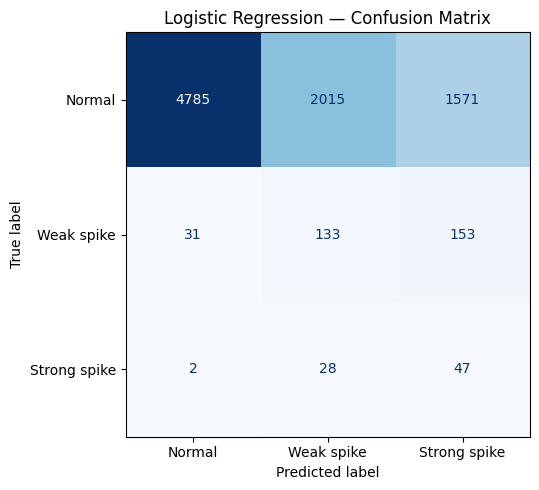

In [38]:
# Evaluate

y_pred = logreg.predict(X_test_sc)

print(classification_report(
    y_test, y_pred,
    target_names=["Normal", "Weak spike", "Strong spike"]
))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=["Normal", "Weak spike", "Strong spike"]).plot(
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()

In [39]:
# Feature coefficients per class
# Large absolute coefficient = feature is informative for that class
# Near-zero across all classes = feature not helpful for spike detection

coef_df = pd.DataFrame(
    logreg.coef_,
    index=["Normal", "Weak spike", "Strong spike"],
    columns=feature_cols
).T

# Max absolute coefficient across classes — overall feature importance proxy
coef_df["max_abs"] = coef_df.abs().max(axis=1)
coef_df = coef_df.sort_values("max_abs", ascending=False)

print("Top 20 most informative features for spike detection:")
print(coef_df.head(20).to_string())

print("\nBottom 10 least informative features:")
print(coef_df.tail(10)[["max_abs"]].to_string())

Top 20 most informative features for spike detection:
                                  Normal  Weak spike  Strong spike   max_abs
el_price_dol_MWh_BEN2201_lag24  1.261899    0.748037     -2.009936  2.009936
el_price_dol_MWh_SFD2201_lag24 -1.632661   -0.302644      1.935305  1.935305
el_price_dol_MWh_ISL2201_lag24 -1.206003    0.055968      1.150035  1.206003
peak_flow_MW_lag24              0.429534    0.747587     -1.177121  1.177121
el_price_dol_MWh_KIK2201_lag24  0.068573   -0.943363      0.874790  0.943363
el_price_dol_MWh_HAY2201_lag24  0.161769    0.742612     -0.904382  0.904382
avg_flow_MW_lag24              -0.161394   -0.733576      0.894970  0.894970
hour_cos                        0.868021   -0.249191     -0.618830  0.868021
target_lag_24h                  0.704830   -0.095340     -0.609490  0.704830
SI_HWE__active_storage_mm³     -0.339411    0.609386     -0.269975  0.609386
rolling_mean_168h               0.516965   -0.229383     -0.287581  0.516965
SI_HWE__lake_level_m  

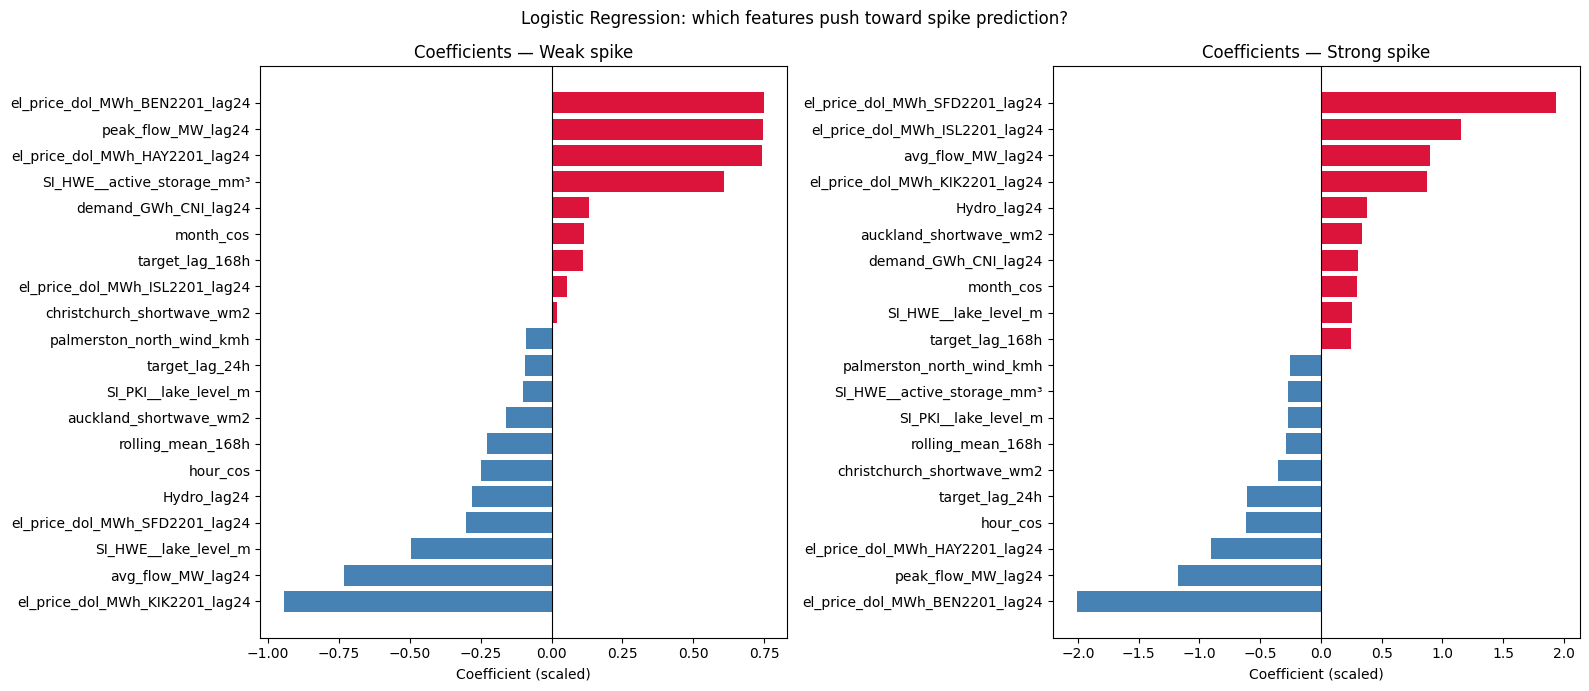

In [40]:
# Plot top 20 coefficients for the spike classes

top20 = coef_df.head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, cls in zip(axes, ["Weak spike", "Strong spike"]):
    vals = top20[cls].sort_values()
    colors = ["crimson" if v > 0 else "steelblue" for v in vals]
    ax.barh(vals.index, vals.values, color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"Coefficients — {cls}")
    ax.set_xlabel("Coefficient (scaled)")

plt.suptitle("Logistic Regression: which features push toward spike prediction?",
             fontsize=12)
plt.tight_layout()
plt.show()